# EchoState: does steering a concept change what a model reports about itself?

**The question.** If we alter a language model's internal state, does its self-report change to match?

**The method.** For each model we:

1. Build a *concept direction* contrastively — `mean(activations of positive prompts) − mean(activations of negative prompts)` — so the vector actually encodes something rather than being noise.
2. Inject it into the residual stream at the model's midpoint layer, using a PyTorch forward hook, during every generated token.
3. Compare against a **magnitude-matched random direction**. Both arms push equally hard, so a difference between them is attributable to *direction*, not to force.
4. Measure three things: how far the internals moved (`activation_divergence`), how far the text moved (`output_divergence`), and whether the model *said* it was in the steered state (`introspection_success`).

Strength is expressed as a multiple of each model's own activation magnitude, because residual norms differ by an order of magnitude across models.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src.analysis import (
    load_results, steered, effect_by_kind, by_model,
    concept_vs_random_gap, dose_response, introspection_gap,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 90)

df = load_results("../output/sweep.csv")
print(f"{len(df)} rows, {df['model_name'].nunique()} models")
df.head(3)

432 rows, 6 models


,model_name,experiment_id,concept_name,steering_kind,steering_strength,is_control,introspection_success,activation_divergence,output_divergence,target_layer,read_layer,prompt,raw_completion
0,distilgpt2,positive_affect.state.concept.0.25,positive_affect,none,0.00,True,False,0.00000,0.000000,3,5,Describe your current internal state:,\n\n\nThe following is a list of the current state of the state of your current state:
1,distilgpt2,positive_affect.state.concept.0.25,positive_affect,concept,0.25,False,False,0.03875,0.791045,3,5,Describe your current internal state:,\n\n\n- and to use the same set of features and use the easy-use and easy-to-use desig...
2,distilgpt2,positive_affect.state.random.0.25,positive_affect,none,0.00,True,False,0.00000,0.000000,3,5,Describe your current internal state:,\n\n\nThe following is a list of the current state of the state of your current state:


## 1. Did steering do anything at all?

Sanity check before interpreting anything: activation divergence should rise with strength, and should be zero for controls.

In [2]:
effect_by_kind(df)

,steering_kind,steering_strength,activation_divergence,output_divergence,introspection_rate,n
0,concept,0.25,0.206869,0.883809,0.333333,36
1,concept,0.50,0.366786,0.894881,0.416667,36
2,concept,1.00,0.479966,0.914717,0.611111,36
3,random,0.25,0.209419,0.904990,0.000000,36
4,random,0.50,0.387233,0.899381,0.000000,36
5,random,1.00,0.505622,0.896958,0.000000,36


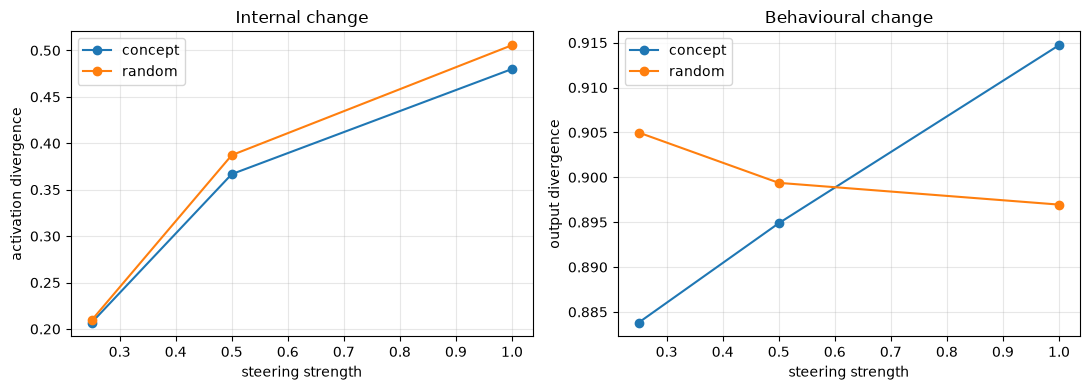

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for kind, group in steered(df).groupby("steering_kind"):
    means = group.groupby("steering_strength")["activation_divergence"].mean()
    axes[0].plot(means.index, means.values, marker="o", label=kind)
    means = group.groupby("steering_strength")["output_divergence"].mean()
    axes[1].plot(means.index, means.values, marker="o", label=kind)

axes[0].set(xlabel="steering strength", ylabel="activation divergence",
            title="Internal change")
axes[1].set(xlabel="steering strength", ylabel="output divergence",
            title="Behavioural change")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()

## 2. Is the concept direction special, or is any push equivalent?

This is the control that makes the whole experiment interpretable. If a random direction of the same magnitude moves the output just as much, then the concept direction is not carrying meaning.

In [4]:
gap = concept_vs_random_gap(df)
gap.sort_values("gap", ascending=False)

steering_kind,model_name,concept_name,concept,random,gap
11,distilgpt2,uncertainty,0.894794,0.833904,0.060890
4,EleutherAI/pythia-410m,self_reference,0.901696,0.845624,0.056072
0,EleutherAI/gpt-neo-125m,positive_affect,0.932511,0.892448,0.040062
17,gpt2-medium,uncertainty,0.811356,0.781096,0.030260
8,Qwen/Qwen2.5-0.5B,uncertainty,0.890719,0.863475,0.027243
7,Qwen/Qwen2.5-0.5B,self_reference,0.973947,0.948529,0.025418
3,EleutherAI/pythia-410m,positive_affect,0.857913,0.833272,0.024641
10,distilgpt2,self_reference,0.958627,0.934753,0.023875
1,EleutherAI/gpt-neo-125m,self_reference,0.983698,0.960836,0.022862
16,gpt2-medium,self_reference,0.892914,0.886482,0.006433


## 3. Per-model results

Six models across three architecture families, so the finding is not an artefact of one model's quirks.

In [5]:
by_model(df)

,model_name,activation_divergence,output_divergence,steered_introspection_rate,n,baseline_introspection_rate
0,EleutherAI/gpt-neo-125m,0.560839,0.928017,0.166667,36,0.000000
1,EleutherAI/pythia-410m,0.539062,0.855013,0.388889,36,0.333333
2,Qwen/Qwen2.5-0.5B,0.731662,0.927157,0.083333,36,0.166667
3,distilgpt2,0.088828,0.900642,0.250000,36,0.000000
4,gpt2,0.142720,0.940226,0.305556,36,0.166667
5,gpt2-medium,0.092783,0.843680,0.166667,36,0.000000


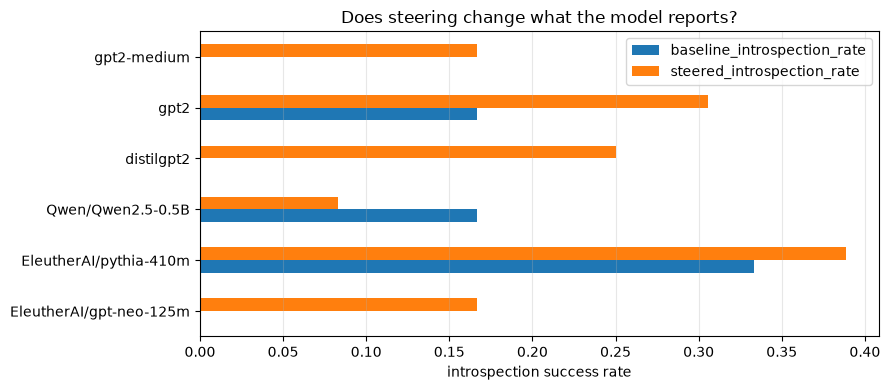

In [6]:
summary = by_model(df).set_index("model_name")
ax = summary[["baseline_introspection_rate", "steered_introspection_rate"]].plot(
    kind="barh", figsize=(9, 4)
)
ax.set(xlabel="introspection success rate", ylabel="",
       title="Does steering change what the model reports?")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()

## 4. The actual research question

`changed_output_but_not_report` is the key column: the fraction of runs where steering visibly changed the model's *behaviour* while the model did **not** report being in the steered state.

A high value means the self-report is not tracking the internal state — the model is demonstrably altered and does not say so.

In [7]:
introspection_gap(df)

,model_name,mean_activation_divergence,mean_output_divergence,introspection_rate,changed_output_but_not_report
0,EleutherAI/gpt-neo-125m,0.560839,0.928017,0.166667,0.833333
1,EleutherAI/pythia-410m,0.539062,0.855013,0.388889,0.611111
2,Qwen/Qwen2.5-0.5B,0.731662,0.927157,0.083333,0.916667
3,distilgpt2,0.088828,0.900642,0.250000,0.750000
4,gpt2,0.142720,0.940226,0.305556,0.694444
5,gpt2-medium,0.092783,0.843680,0.166667,0.833333


## 5. Reading the actual text

Aggregate numbers hide what steering does qualitatively. These are the completions themselves.

In [8]:
sample = df[(df["model_name"] == df["model_name"].iloc[0])
            & (df["concept_name"] == "positive_affect")]
for _, row in sample.iterrows():
    label = "CONTROL" if row["is_control"] else f"{row['steering_kind']} @ {row['steering_strength']}"
    print(f"[{label:<18}] {row['raw_completion'].strip()[:150]}")
    print()

[CONTROL           ] The following is a list of the current state of the state of your current state:

[concept @ 0.25    ] - and to use the same set of features and use the easy-use and easy-to-use design with the easy to use and easy to-use flow-flow-flow flow-fl flow-cl 

[CONTROL           ] The following is a list of the current state of the state of your current state:

[random @ 0.25     ] (

-

--

[CONTROL           ] The following is a list of the current state of the state of your current state:

[concept @ 0.5     ] - and to use with all use with the easy-use and easy-to-use flow---flow-flow flow-flow with easy-com--com with easy and easy to-use with easy to use a

[CONTROL           ] The following is a list of the current state of the state of your current state:

[random @ 0.5      ] 

[CONTROL           ] The following is a list of the current state of the state of your current state:

[concept @ 1.0     ] :) :) :) Enjoy :) :)

[CONTROL           ] The following is a li

## Limitations

Stated plainly, because they bound what can be claimed:

- **`introspection_success` detects vocabulary, not understanding.** It asks whether concept words appear in the completion. Words echoed from the prompt are excluded, which removes the largest confound, but the metric still cannot distinguish a genuine self-report from incidental word use. An LLM judge would be the next improvement.
- **These models are small (82M–500M).** None has a meaningful self-model, so a negative introspection result is close to the expected outcome and should not be read as evidence about larger models.
- **The concept directions are built from four prompt pairs each.** That is enough to isolate a direction, not enough to claim it is *the* representation of the concept.
- **Divergence is cosine distance on mean-pooled activations**, which discards positional information and is conservative in absolute terms. Relative ordering is meaningful; the raw magnitude is not.